In [4]:
# Установим библиотеку для работы с датасетами на kaggle
!pip install opendatasets --quiet

In [5]:
import opendatasets as od

# Загрузим датасет на прямую с kaggle
dataset_url = 'https://www.kaggle.com/competitions/home-data-for-ml-course'

# Upload Kaggle.json file to Colab… (Caution: Do not Share kaggle.json as contains API key of your Kaggle Account)

od.download(dataset_url)

Skipping, found downloaded files in "./home-data-for-ml-course" (use force=True to force download)


In [272]:
import pandas as pd

train = pd.read_csv('/Users/ignatus/Downloads/home-data-for-ml-course/train.csv')
test = pd.read_csv('/Users/ignatus/Downloads/home-data-for-ml-course/test.csv')
sample_submit = pd.read_csv('/Users/ignatus/Downloads/home-data-for-ml-course/sample_submission.csv')
train.head(100)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,60,RL,NaN,9765,Pave,NaN,IR2,Lvl,AllPub,...,0,NaN,NaN,Shed,480,4,2009,WD,Normal,185000
96,97,20,RL,78.0,10264,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2006,WD,Normal,214000
97,98,20,RL,73.0,10921,Pave,NaN,Reg,HLS,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,94750
98,99,30,RL,85.0,10625,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,Shed,400,5,2010,COD,Abnorml,83000


array([[<Axes: title={'center': 'Id'}>,
        <Axes: title={'center': 'MSSubClass'}>,
        <Axes: title={'center': 'LotFrontage'}>,
        <Axes: title={'center': 'LotArea'}>,
        <Axes: title={'center': 'OverallQual'}>,
        <Axes: title={'center': 'OverallCond'}>],
       [<Axes: title={'center': 'YearBuilt'}>,
        <Axes: title={'center': 'YearRemodAdd'}>,
        <Axes: title={'center': 'MasVnrArea'}>,
        <Axes: title={'center': 'BsmtFinSF1'}>,
        <Axes: title={'center': 'BsmtFinSF2'}>,
        <Axes: title={'center': 'BsmtUnfSF'}>],
       [<Axes: title={'center': 'TotalBsmtSF'}>,
        <Axes: title={'center': '1stFlrSF'}>,
        <Axes: title={'center': '2ndFlrSF'}>,
        <Axes: title={'center': 'LowQualFinSF'}>,
        <Axes: title={'center': 'GrLivArea'}>,
        <Axes: title={'center': 'BsmtFullBath'}>],
       [<Axes: title={'center': 'BsmtHalfBath'}>,
        <Axes: title={'center': 'FullBath'}>,
        <Axes: title={'center': 'HalfBath'}>,

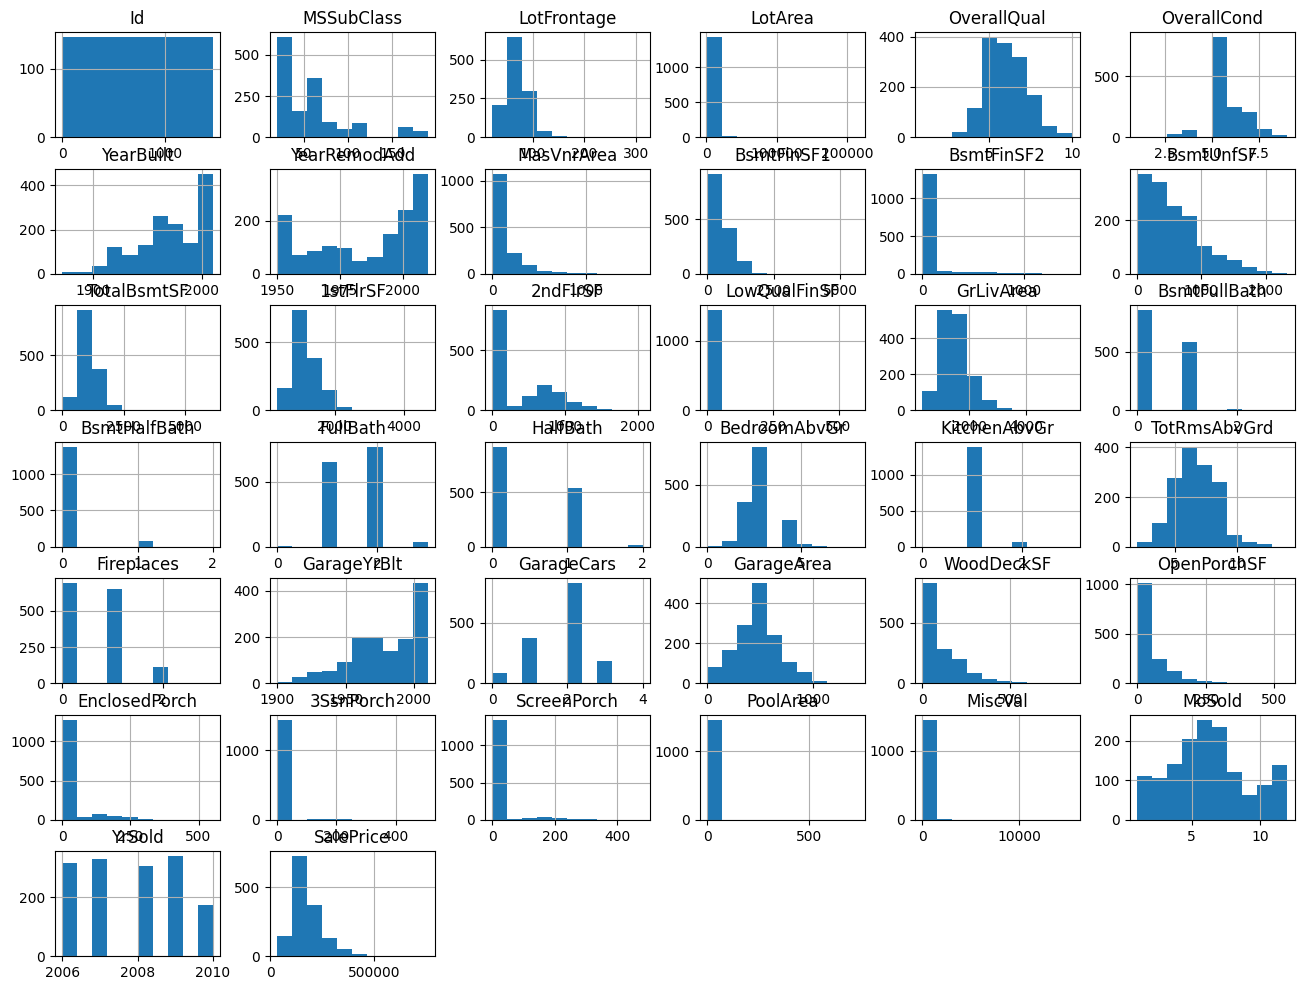

In [273]:
train.hist(figsize=(16, 12))

In [274]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [275]:
#categorical_features = train.drop(columns=['SalePrice']).select_dtypes(include= object).columns.values
#categorical_features

In [276]:
numeric_features = train.drop(columns=['SalePrice']).select_dtypes(exclude= object).columns.values
numeric_features

<StringArray>
[           'Id',    'MSSubClass',   'LotFrontage',       'LotArea',
   'OverallQual',   'OverallCond',     'YearBuilt',  'YearRemodAdd',
    'MasVnrArea',    'BsmtFinSF1',    'BsmtFinSF2',     'BsmtUnfSF',
   'TotalBsmtSF',      '1stFlrSF',      '2ndFlrSF',  'LowQualFinSF',
     'GrLivArea',  'BsmtFullBath',  'BsmtHalfBath',      'FullBath',
      'HalfBath',  'BedroomAbvGr',  'KitchenAbvGr',  'TotRmsAbvGrd',
    'Fireplaces',   'GarageYrBlt',    'GarageCars',    'GarageArea',
    'WoodDeckSF',   'OpenPorchSF', 'EnclosedPorch',     '3SsnPorch',
   'ScreenPorch',      'PoolArea',       'MiscVal',        'MoSold',
        'YrSold']
Length: 37, dtype: str

In [277]:
train['SalePrice'] = train['SalePrice'].astype(int)

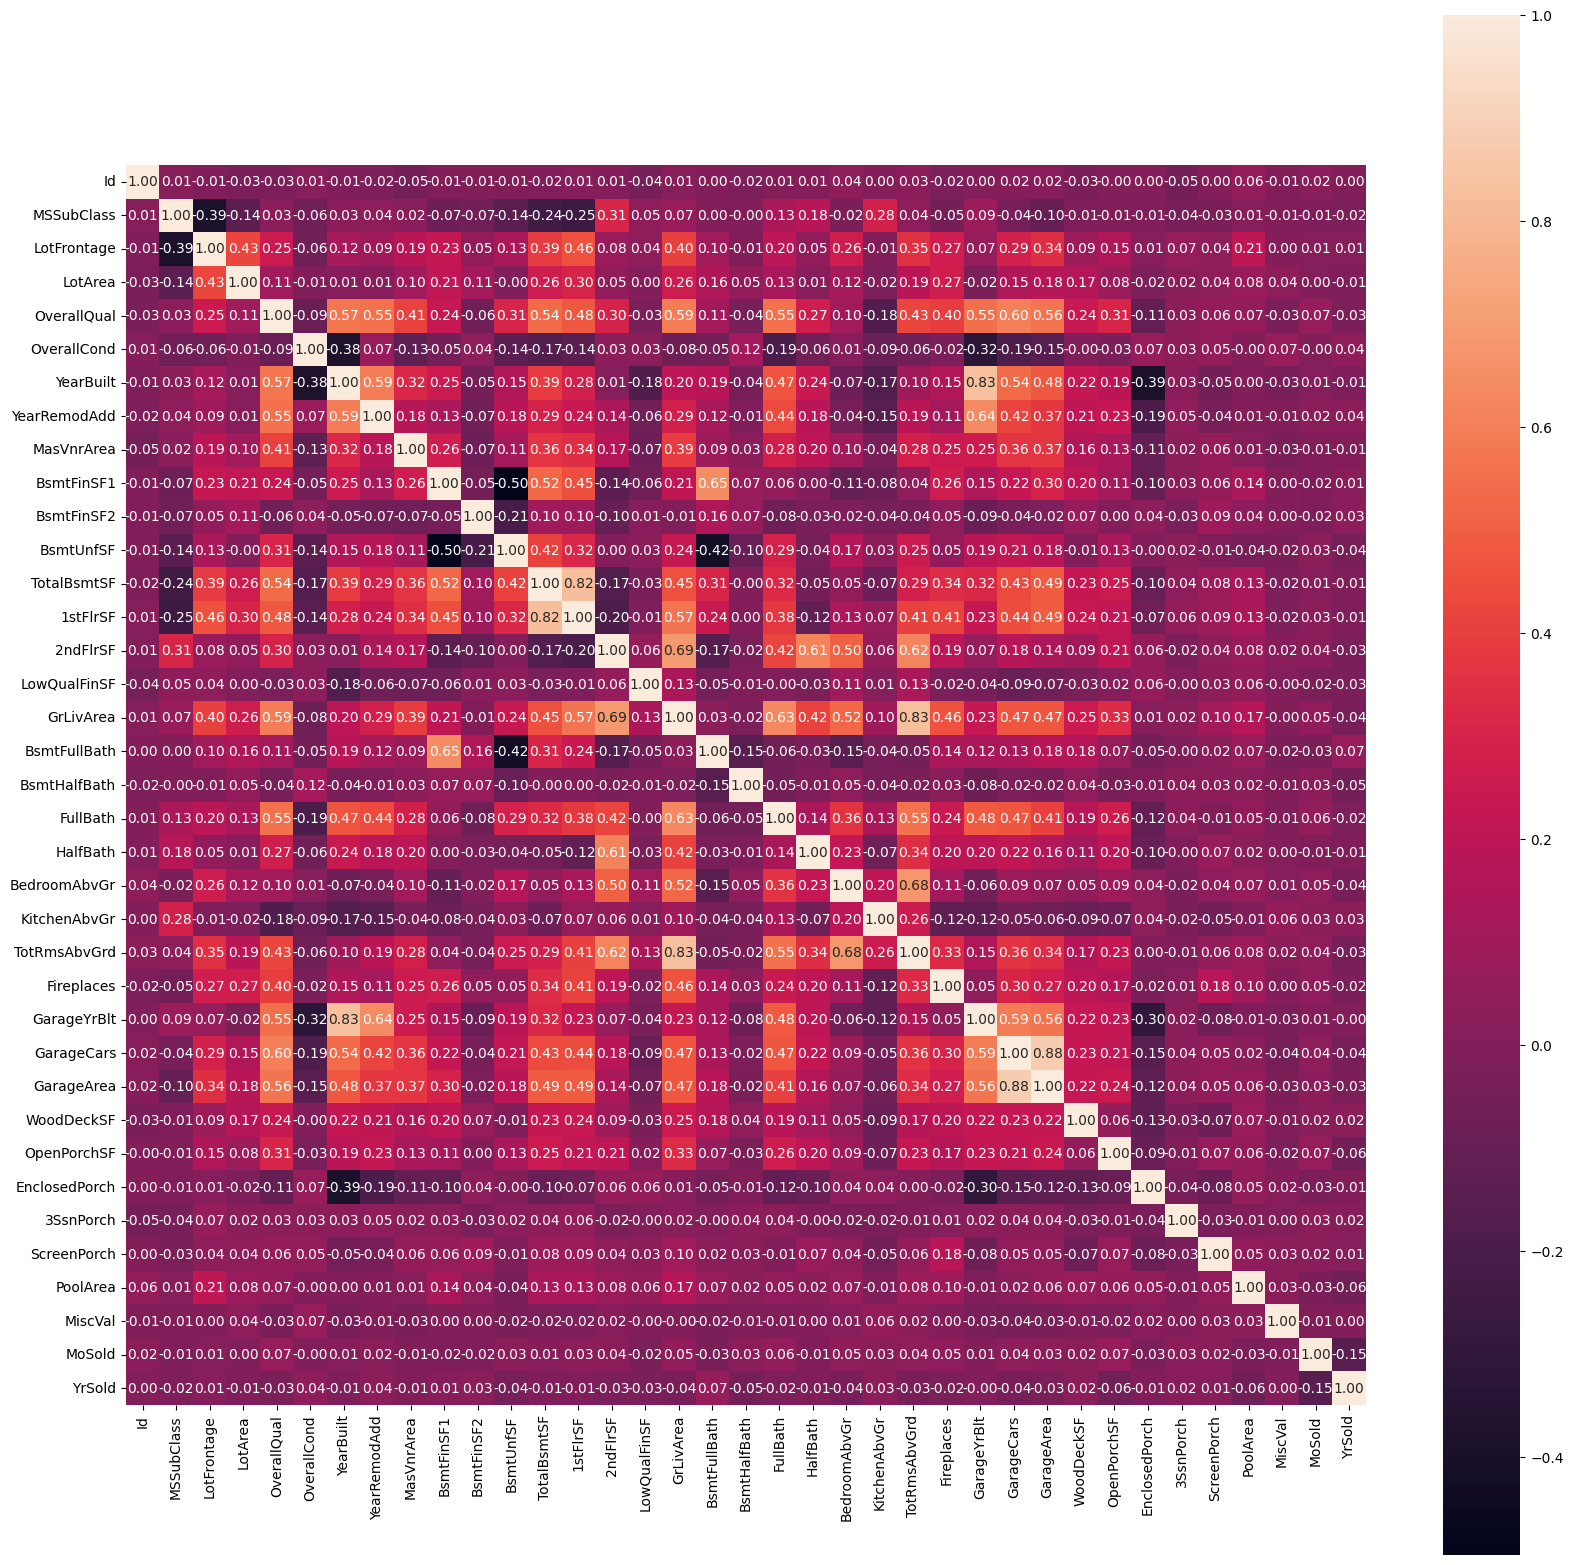

In [278]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.subplots(figsize=(20, 20))
sns.heatmap(train[numeric_features].corr(),fmt='.2f', square = True, annot=True)
plt.show()

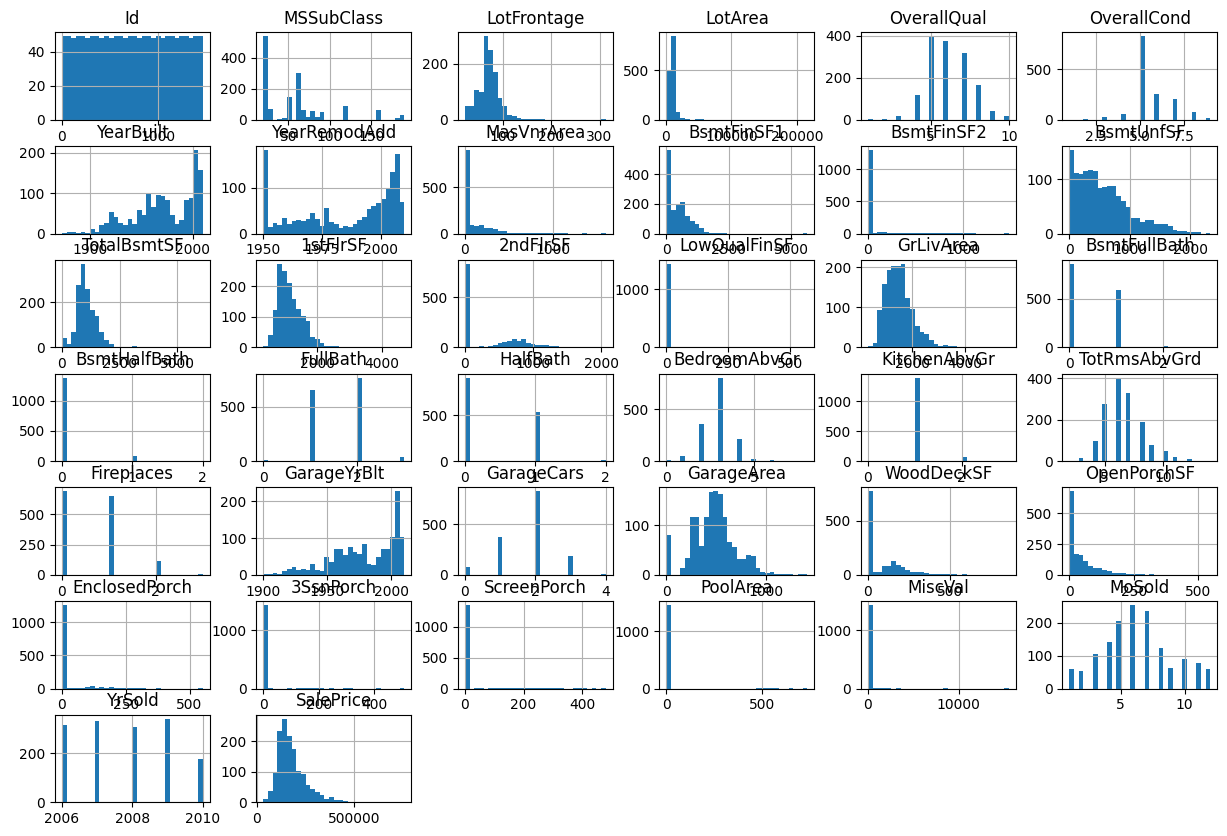

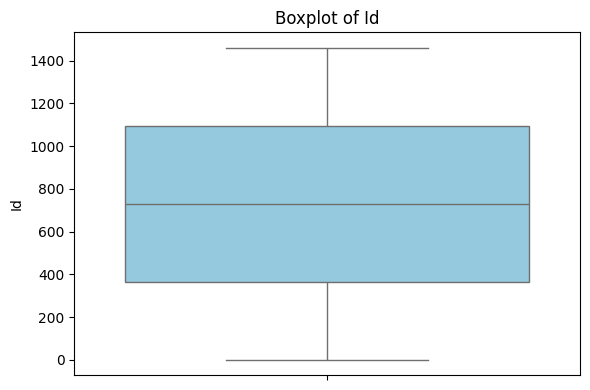

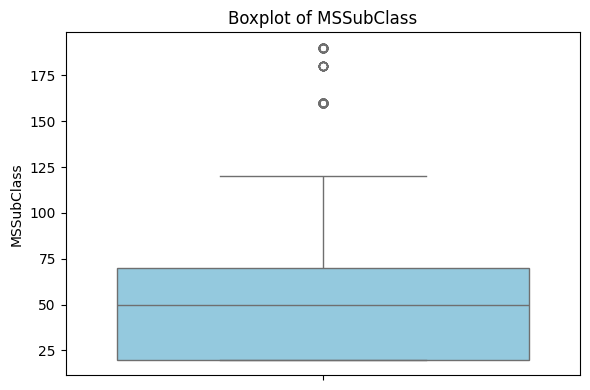

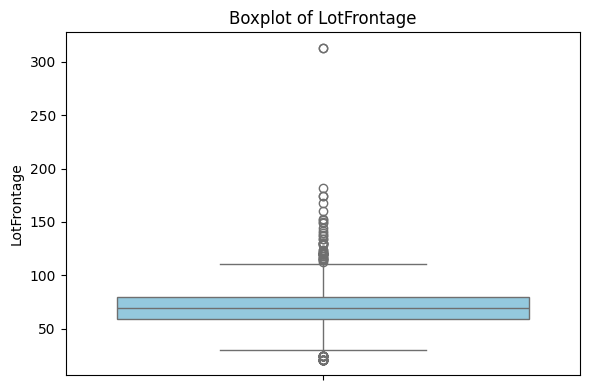

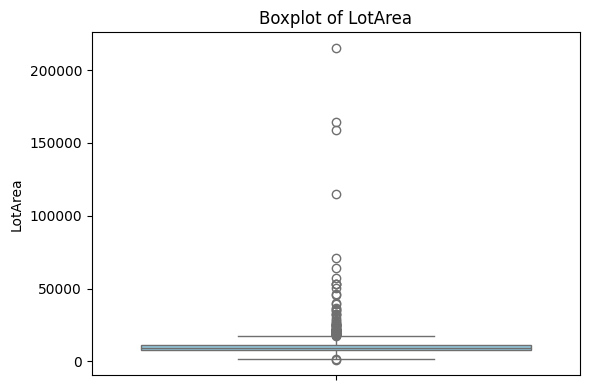

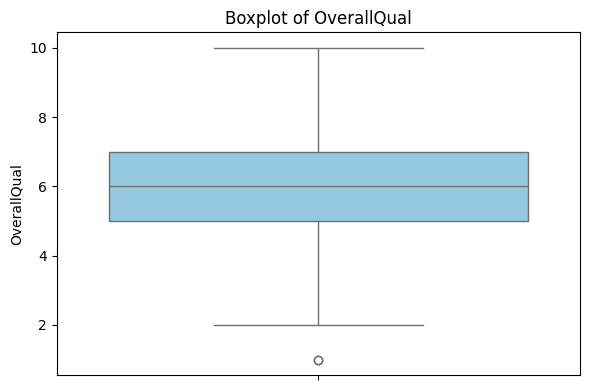

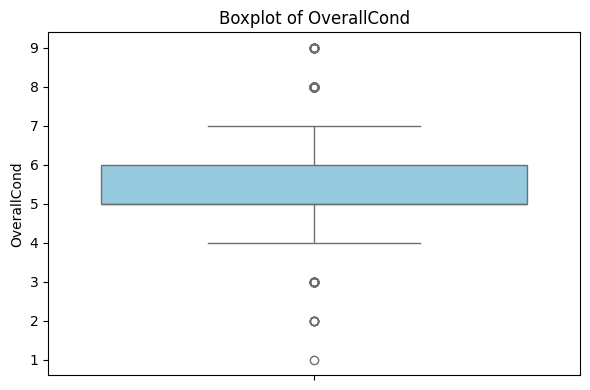

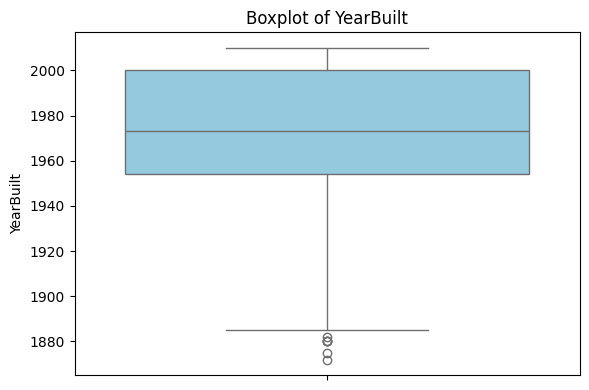

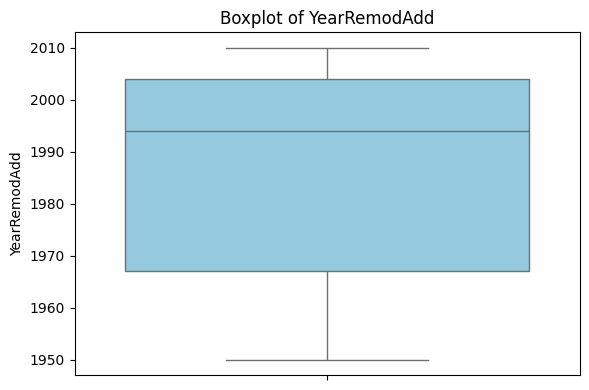

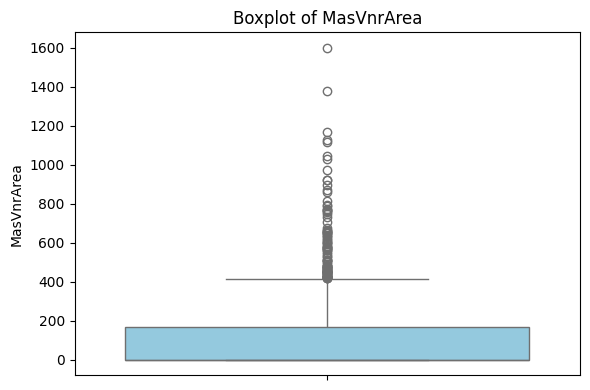

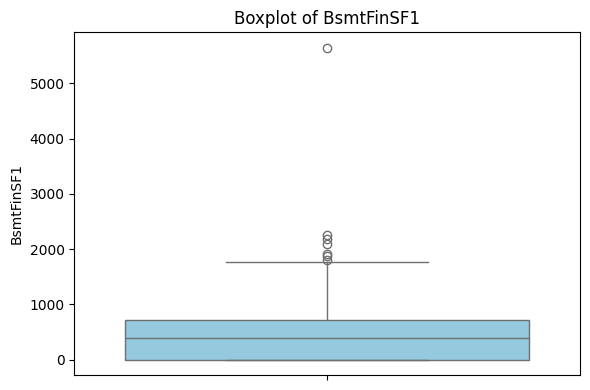

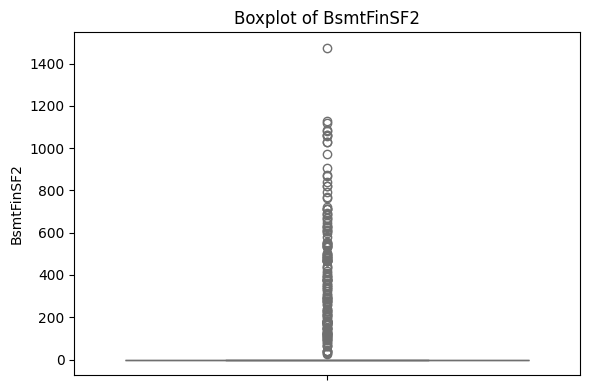

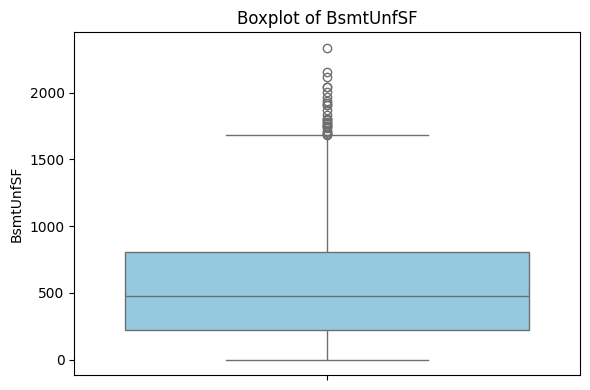

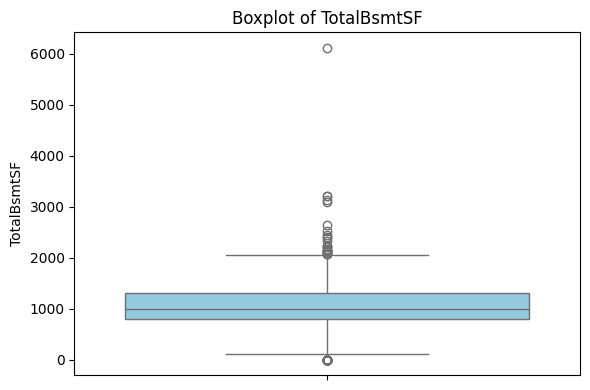

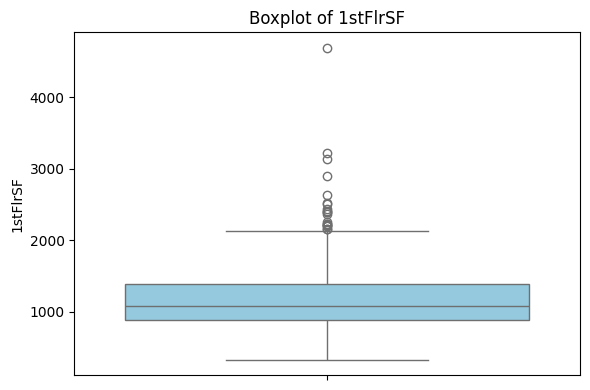

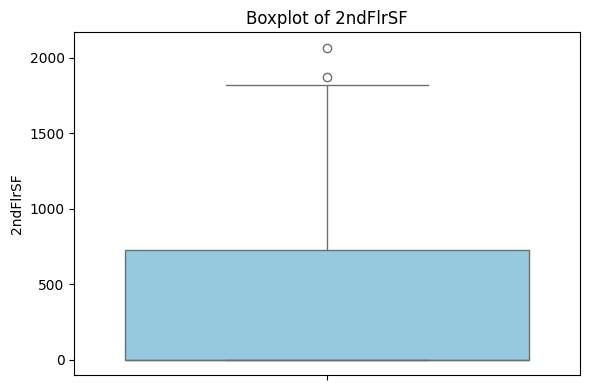

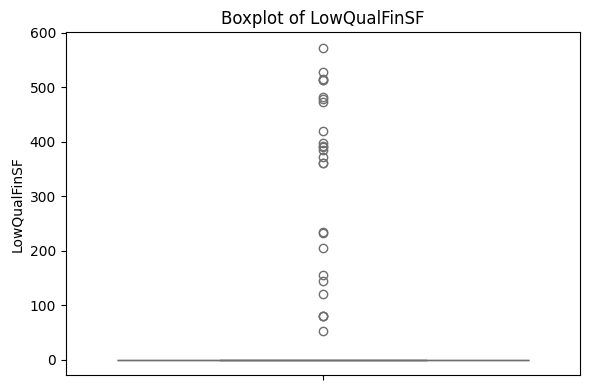

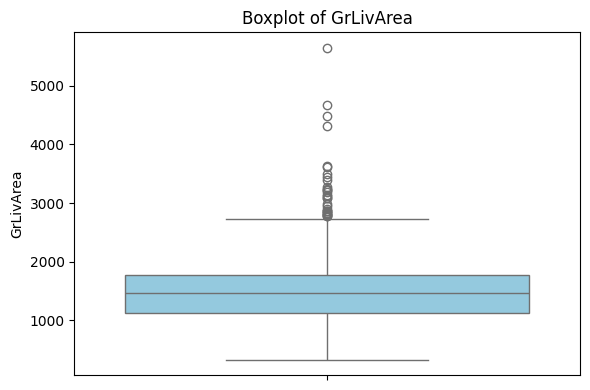

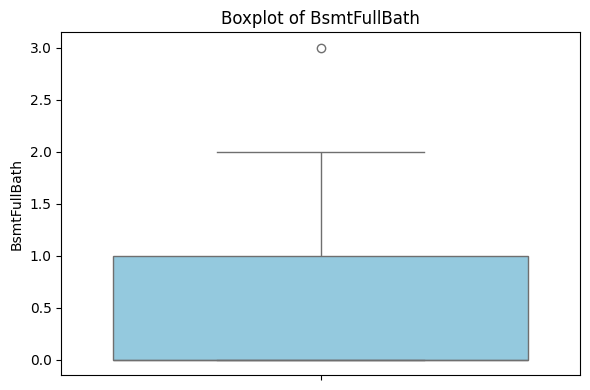

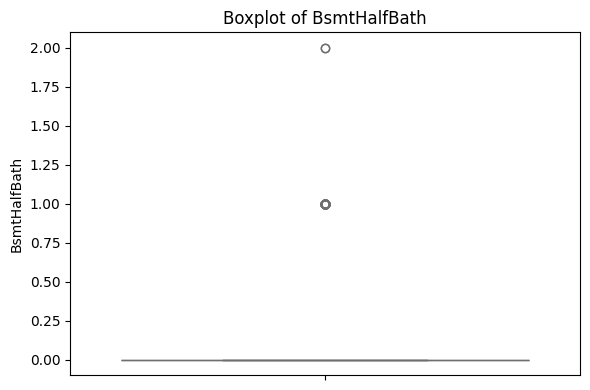

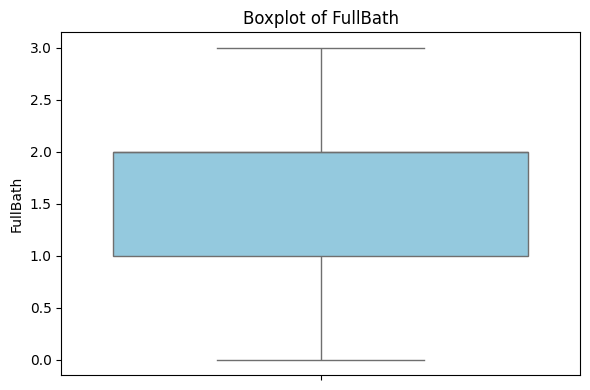

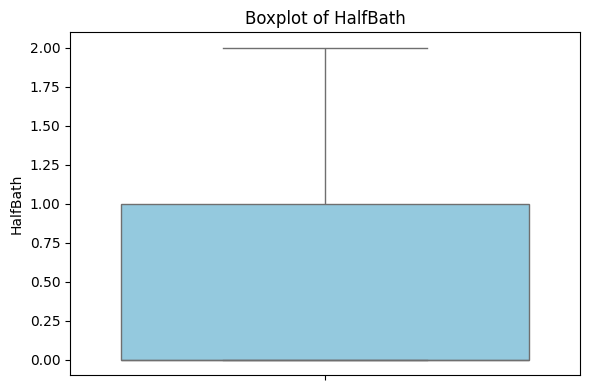

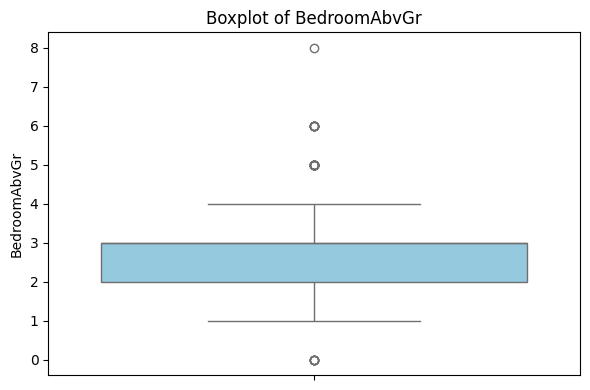

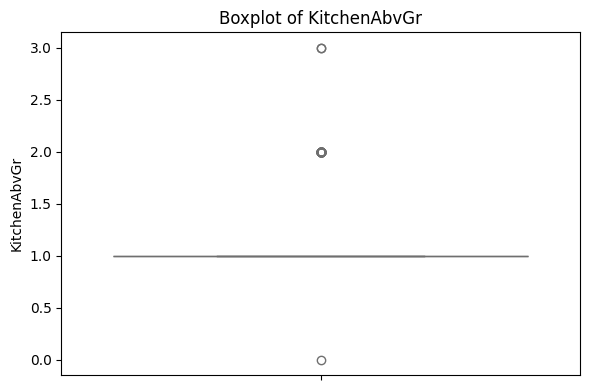

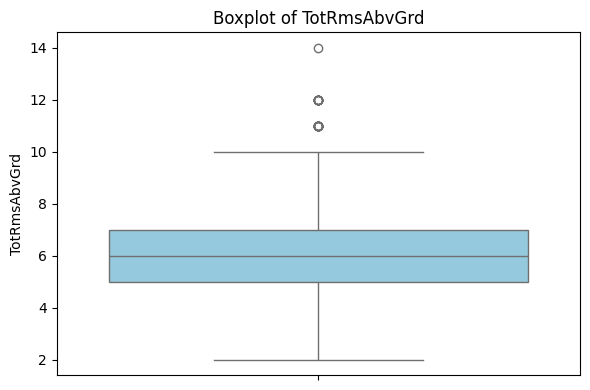

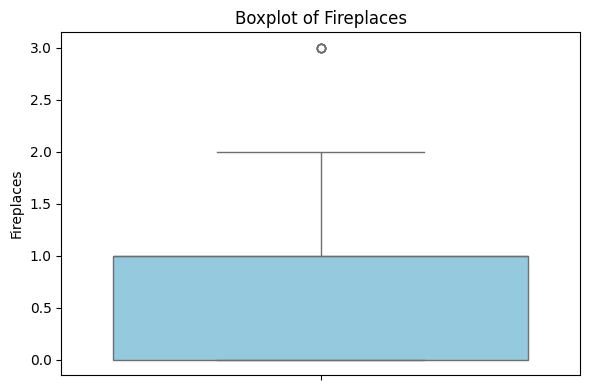

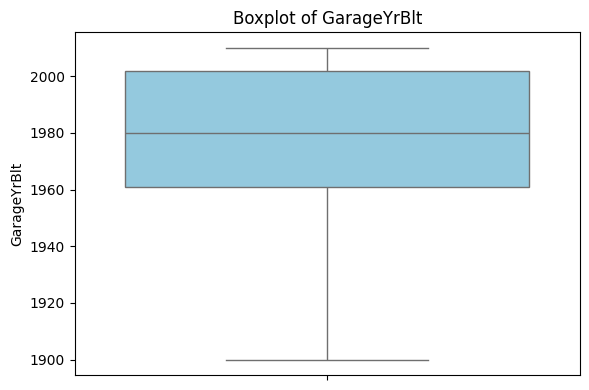

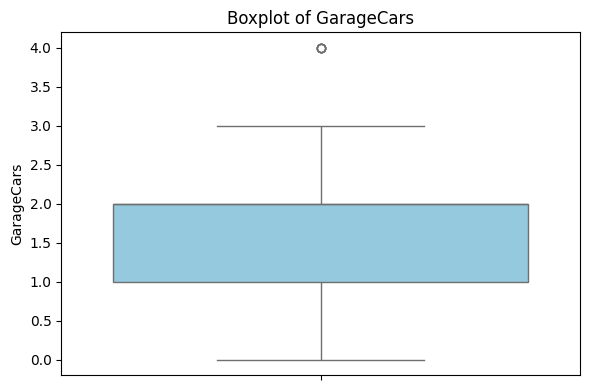

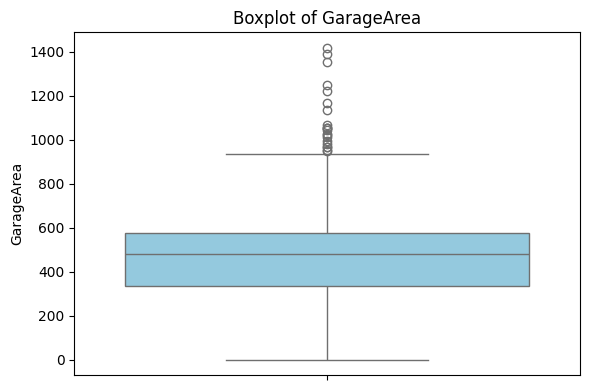

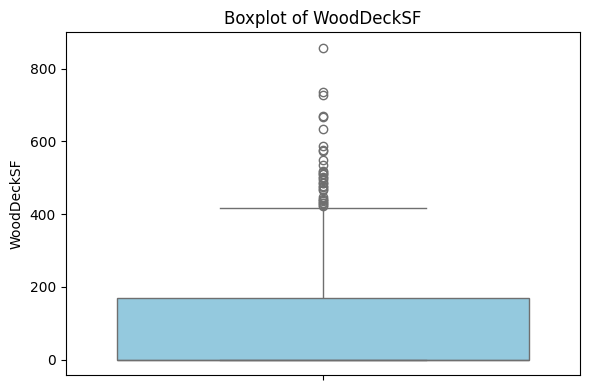

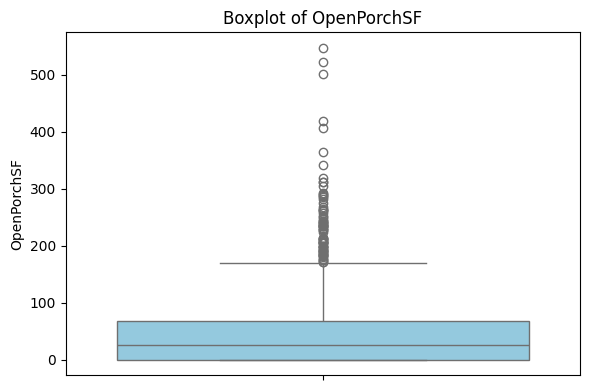

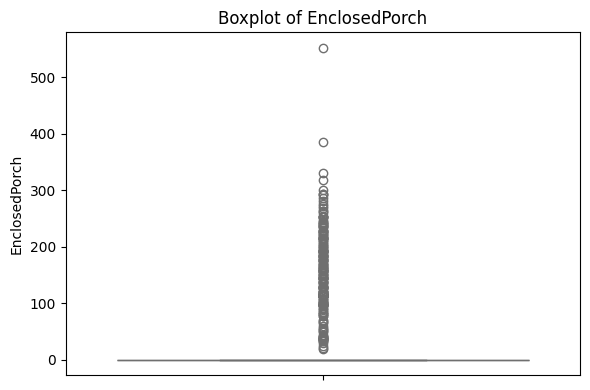

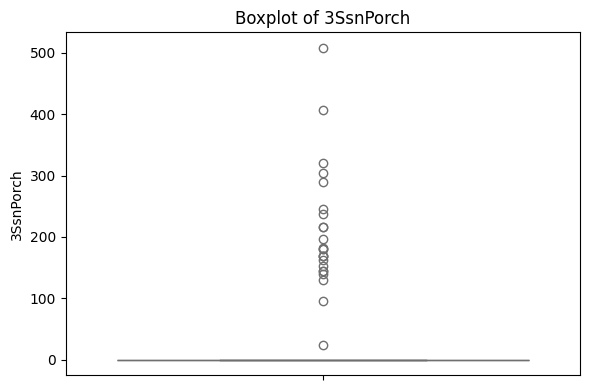

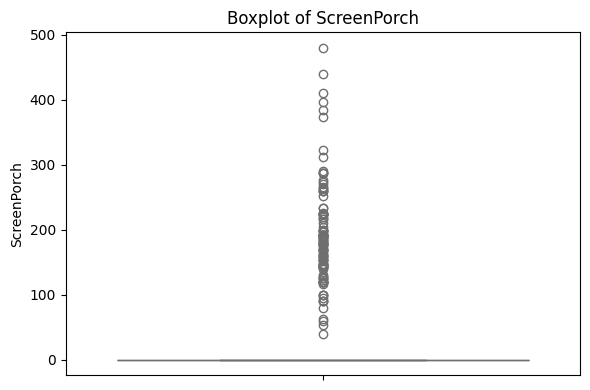

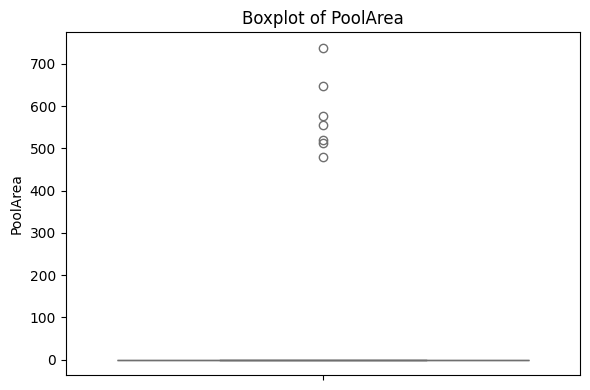

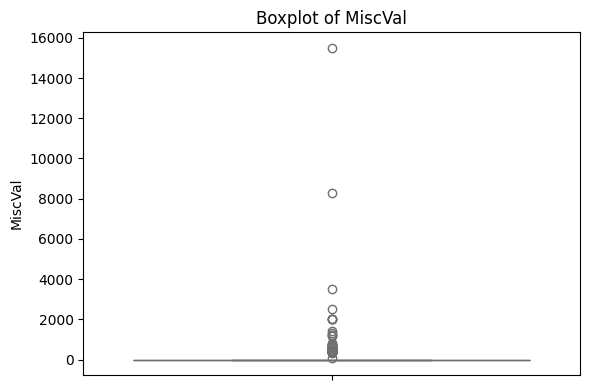

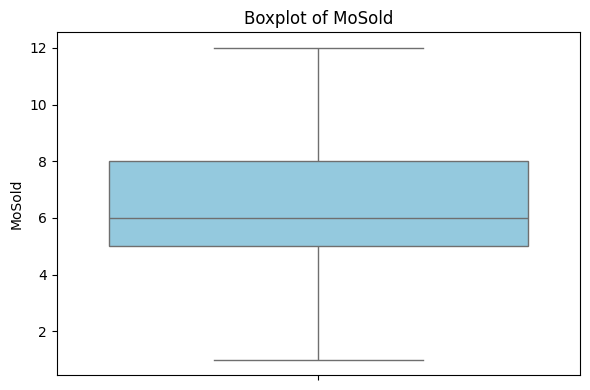

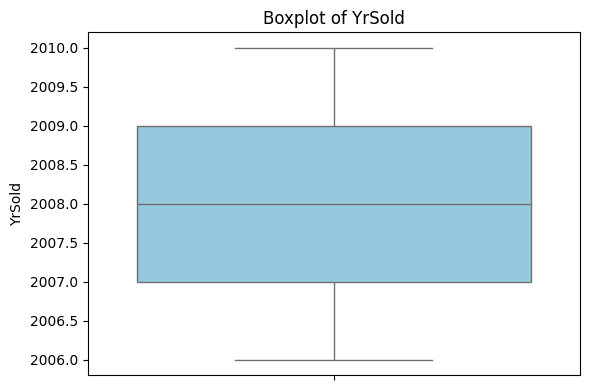

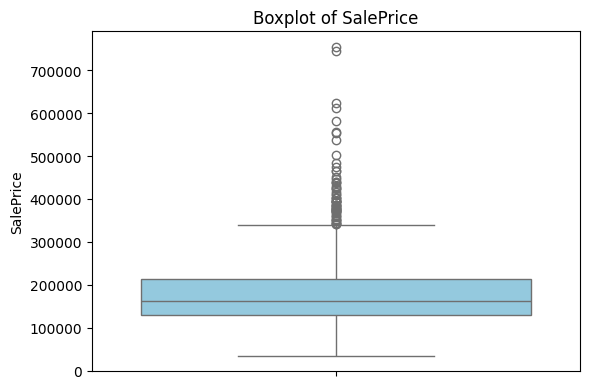

In [279]:
train.hist(bins=30, figsize=(15, 10))
plt.show()
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузите ваш DataFrame
# df = pd.read_csv('your_data.csv')

# Выбираем числовые колонки
numeric_cols = train.select_dtypes(include=['int64', 'float64']).columns

if len(numeric_cols) == 0:
    print("Нет числовых колонок.")
else:
    for col in numeric_cols:
        plt.figure(figsize=(6, 4))  # создаём новую фигуру
        sns.boxplot(y=train[col], color='skyblue')
        plt.title(f'Boxplot of {col}')
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()  # в Jupyter каждый график появится последовательно

In [280]:
train['YrSold'].nunique()

5

In [281]:
train.columns


Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [282]:
cols_to_logStd_median = ['MSSubClass','LotFrontage','LotArea','YearBuilt','YearRemodAdd','MasVnrArea','BsmtFinSF1','BsmtFinSF2','BsmtUnfSF','TotalBsmtSF','1stFlrSF','2ndFlrSF','GrLivArea','GarageYrBlt','GarageArea','WoodDeckSF','OpenPorchSF','EnclosedPorch','ScreenPorch']
#object_features = train.drop(columns=['SalePrice']).select_dtypes(include= object).columns.values
categorial_cols = ['OverallQual','OverallCond','LowQualFinSF','BsmtFullBath','BsmtHalfBath','FullBath','HalfBath','BedroomAbvGr','KitchenAbvGr','TotRmsAbvGrd','Fireplaces','GarageCars','3SsnPorch','PoolArea','MiscVal','MoSold','YrSold']

In [283]:
from sklearn.model_selection import train_test_split

cols_to_remove = ['Alley','PoolQC','MiscFeature','Fence','FireplaceQu','MasVnrType']
train_clean = train.drop(columns=cols_to_remove, errors='ignore')

X_train, X_test, y_train, y_test = train_test_split(train_clean.drop(columns = ['SalePrice']), train['SalePrice'], test_size=0.2, random_state=42)
X_train.info()

<class 'pandas.DataFrame'>
Index: 1168 entries, 254 to 1126
Data columns (total 74 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1168 non-null   int64  
 1   MSSubClass     1168 non-null   int64  
 2   MSZoning       1168 non-null   str    
 3   LotFrontage    951 non-null    float64
 4   LotArea        1168 non-null   int64  
 5   Street         1168 non-null   str    
 6   LotShape       1168 non-null   str    
 7   LandContour    1168 non-null   str    
 8   Utilities      1168 non-null   str    
 9   LotConfig      1168 non-null   str    
 10  LandSlope      1168 non-null   str    
 11  Neighborhood   1168 non-null   str    
 12  Condition1     1168 non-null   str    
 13  Condition2     1168 non-null   str    
 14  BldgType       1168 non-null   str    
 15  HouseStyle     1168 non-null   str    
 16  OverallQual    1168 non-null   int64  
 17  OverallCond    1168 non-null   int64  
 18  YearBuilt      1168 no

In [284]:
'''
train = train.drop(columns=['Alley','PoolQC','MiscFeature','Fence','FireplaceQu','MasVnrType'])
train.info()
'''

"\ntrain = train.drop(columns=['Alley','PoolQC','MiscFeature','Fence','FireplaceQu','MasVnrType'])\ntrain.info()\n"

In [289]:
from sklearn.pipeline import make_pipeline # конвейер подготовки данных
from sklearn.pipeline import Pipeline # конвер алгоритмов
from sklearn.impute import SimpleImputer # пропуски заполняются медианными значениями
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer # onehot encoding и стандартизации
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
import numpy as np  # Добавьте эту строку в начало
from sklearn.ensemble import HistGradientBoostingRegressor

object_features = X_train.select_dtypes(include='object').columns.values


# Создаем трансформер, который вызывает функцию drop
# validate=False разрешает передавать DataFrame (иначе sklearn ждет numpy массив)
dropper = FunctionTransformer(
    lambda df: df.drop(columns=cols_to_remove, errors='ignore'), 
    validate=False
)


numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy="median")),
    ('log', FunctionTransformer(np.log1p, validate=False)),
    ('scaler', StandardScaler())
])


categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy="most_frequent")),
    ('onehot', OneHotEncoder(handle_unknown='ignore',sparse_output=False))
])

# конвейер подготовки данных категориального типа
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, cols_to_logStd_median),
        ('cat', categorical_pipeline, list(object_features) + categorial_cols)
    ],
    remainder='drop', # Остальные колонки (если вдруг что-то пропустили) удаляем
    verbose_feature_names_out=False
)
'''
all_required_cols = set(cols_to_logStd_median + categorial_cols + list(object_features))
current_cols = set(X_train.columns)
missing = all_required_cols - current_cols
if missing:
    print(f"Отсутствуют колонки в X_train: {missing}")

print("=== Проверка cols_to_logStd_median ===")
for i, col in enumerate(cols_to_logStd_median):
    if not isinstance(col, str):
        print(f"❌ [{i}] {repr(col)} — тип: {type(col)}")

print("\n=== Проверка categorial_cols ===")
for i, col in enumerate(categorial_cols):
    if not isinstance(col, str):
        print(f"❌ [{i}] {repr(col)} — тип: {type(col)}")

print("\n=== Проверка object_features ===")
for i, col in enumerate(object_features):
    if not isinstance(col, str):
        print(f"❌ [{i}] {repr(col)} — тип: {type(col)}")

# Также проверим, есть ли в списках реальные колонки из X_train
all_cols = set(X_train.columns)
for name, lst in [('numeric', cols_to_logStd_median), 
                  ('categorial', categorial_cols),
                  ('object', object_features)]:
    missing = [c for c in lst if c not in all_cols]
    if missing:
        print(f"\n⚠️ {name}: не найдены в X_train: {missing[:5]}...")
'''
# подготовка и обучение алгоритма
'''
alg = Pipeline(steps=[
    #('drop', dropper),       # Сначала чистим имена колонок
    ('preprocess', preprocessor), # Потом превращаем в цифры
    ('model', RandomForestRegressor(random_state=42))
])


# обучение алгоритма
alg.fit(X_train, y_train)
'''
alg_hgb = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', HistGradientBoostingRegressor(random_state=42))
])
alg_hgb.fit(X_train, y_train)

/var/folders/_t/byhz82tx7qxfq__l45xjrxg00000gn/T/ipykernel_27023/2889323601.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_features = X_train.select_dtypes(include='object').columns.values


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [290]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, median_absolute_error
# предсказания
preds = alg.predict(X_test)

# коэффициент детерминации и медианна абсолютная ошибка
r2_score(y_test, preds), median_absolute_error(y_test, preds)

(0.8881484228272876, 9906.384999999995)

In [291]:
# среднее и стандартное отклонение целевой переменной
y_test.mean(), y_test.std()

(np.float64(178839.81164383562), np.float64(87730.75125912335))

In [293]:
from sklearn.model_selection import GridSearchCV
'''
# Ваш оригинальный, хорошо работающий вариант
parameters = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__max_depth': [5, 10, 15, 20, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]  # можно добавить
}

gs = GridSearchCV(
    alg,
    parameters,
    cv=5,
    scoring='neg_root_mean_squared_error',  # или 'r2'
    verbose=2,
    n_jobs=-1
)

gs.fit(X_train, y_train)

print(f"✅ Лучшие параметры: {gs.best_params_}")
print(f"✅ Лучший RMSE: {-gs.best_score_:.2f}")
print(f"✅ Лучший R²: {gs.best_score_:.4f}")
'''
param_grid_hgb = {
    'model__max_iter': [100, 200, 300],
    'model__max_depth': [3, 5, 7, None],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__l2_regularization': [0, 0.01, 0.1]
}

gs_hgb = GridSearchCV(
    alg_hgb, 
    param_grid_hgb, 
    cv=5, 
    scoring='neg_root_mean_squared_error',  # ✅ Правильное название!
    n_jobs=-1, 
    verbose=2
)
gs_hgb.fit(X_train, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__l2_regularization': [0, 0.01, ...], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 5, ...], 'model__max_iter': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messag

In [295]:
'''
preds = gs.best_estimator_.predict(X_test)

r2_score(y_test, preds), median_absolute_error(y_test, preds)
'''
preds = gs_hgb.best_estimator_.predict(X_test)

r2_score(y_test, preds), median_absolute_error(y_test, preds)

(0.8929595749039212, 11135.7307626053)

In [268]:
#Подготовка данных для загрузки на Kaggle

In [296]:
final_test_clean = test.drop(columns=cols_to_remove, errors='ignore')

final_predictions = gs_hgb.best_estimator_.predict(final_test_clean)

print(sample_submit.info())

sample_submit['SalePrice'] = final_predictions

sample_submit.to_csv('my_submit_SalePrice.csv', index=False)


<class 'pandas.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Id         1459 non-null   int64  
 1   SalePrice  1459 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 22.9 KB
None


In [226]:
os.getcwd()

'/Users/ignatus/Downloads'